# Un peu de statistiques

[voir Learning Statistics with Python](https://ethanweed.github.io/pythonbook/landingpage.html)
et pour une traduction française, [Apprentissage des statistiques avec Jamovi](https://jmeunierp8.github.io/ManuelJamovi/) (mais pas avec Python).

## À quoi servent les statistiques ?

Imaginez qu'on vous remette un tableau de **176 lignes** contenant les résultats de matchs de foot australien. Que pouvez-vous en dire ? Difficile d'y voir clair en lisant les nombres un par un.

Les **statistiques descriptives** servent exactement à ça : **résumer** un gros paquet de chiffres par quelques valeurs simples qui en donnent une idée fidèle.

C'est un peu comme la météo : au lieu de vous donner la température seconde par seconde, on vous dit *« il fera 18° en moyenne avec des pointes à 25° »*. Vous avez perdu du détail, mais gagné en clarté.

Dans ce notebook, on va voir :
- comment résumer **où se situent** les données (moyenne, médiane, mode) ;
- comment mesurer **à quel point elles sont étalées** (variance, écart-type, IQR) ;
- quelques **lois de probabilité** classiques (binomiale, normale) qui servent à modéliser le hasard.

**Le jeu de données :** on va s'intéresser à des données de la Ligue australienne de football (AFL).

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
afl_finalists = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_finalists.csv')
afl_margins = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_margins.csv')

# afl_finalists = pd.read_csv('../../data/afl_finalists.csv')
# afl_margins = pd.read_csv('../../data/afl_margins.csv')

margins = afl_margins["afl.margins"]
finalists = afl_finalists["afl.finalists"]

In [2]:
margins.head()

0    56
1    31
2    56
3     8
4    32
Name: afl.margins, dtype: int64

La variable `margins` contient la marge gagnante (nombre de points) pour les 176 matchs joués à domicile et à l’extérieur durant la saison 2010

Regarder les données ne suffit pas. On peut les représenter graphiquement. Par exemple ici à l'aide d'un histogramme

[Text(0.5, 0, 'Marge gagnante'), Text(0, 0.5, 'Occurrences')]

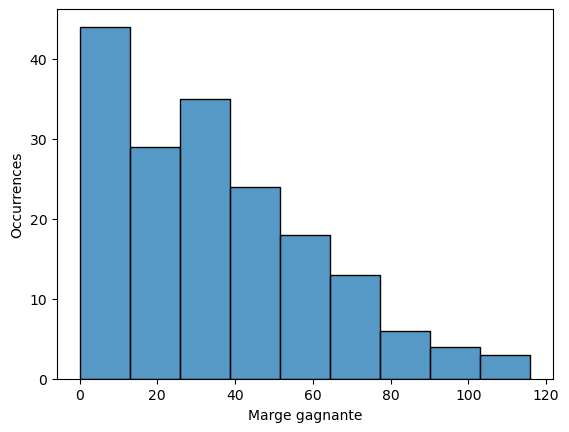

In [3]:
import seaborn as sns
ax = sns.histplot(margins)
ax.set(xlabel ="Marge gagnante", ylabel = "Occurrences")

## Différents types de données

![Data Types](../../images/data-types.png)

##  Mesures de la tendance centrale


### La moyenne

**L'idée en une phrase :** on additionne toutes les valeurs et on divise par leur nombre. C'est la valeur que chacun aurait si on *répartissait équitablement* le total.

> *Exemple concret :* si 4 personnes ont 10, 20, 30 et 40 euros, la moyenne est $(10+20+30+40)/4 = 25$. C'est ce que chaque personne aurait si on mettait tout en commun et qu'on partageait en parts égales.

#### La formule

$
\Large {
\bar{X} = \frac{1}{N} \sum_{i=1}^N X_i
}
$

**Décodons chaque symbole** (c'est plus simple qu'il n'y paraît) :

| Symbole | Se lit | Ce que ça veut dire |
|---|---|---|
| $\bar{X}$ | "X barre" | La moyenne qu'on cherche à calculer |
| $N$ | — | Le nombre total de valeurs (par ex. 176 matchs) |
| $X_i$ | "X indice i" | La $i$-ème valeur (le 1er match, le 2ème, ...) |
| $\sum_{i=1}^N$ | "somme de $i=1$ jusqu'à $N$" | On additionne : $X_1 + X_2 + \dots + X_N$ |
| $\frac{1}{N}$ | — | On divise par $N$ |

Autrement dit, la formule dit exactement : **« fais la somme de tout, puis divise par le nombre »**. Le symbole $\sum$ (sigma grec majuscule) fait peur mais c'est juste une manière compacte d'écrire « addition ».

In [4]:
print(f"X_mean = {margins.mean():.2f}")

X_mean = 35.30


### La médiane

**L'idée en une phrase :** on trie les valeurs, et la médiane est **celle du milieu**. Autant de valeurs en dessous, autant au-dessus.

> *Pourquoi c'est utile ?* Parce que la médiane se moque des valeurs extrêmes. Si vous avez 9 salaires normaux et celui de Bill Gates, la moyenne explose, mais la médiane reste à peu près celle d'un salaire normal (on verra l'exemple juste après).

Regardons 5 valeurs de nos marges :

In [5]:
margins.head().sort_values()

3     8
1    31
4    32
0    56
2    56
Name: afl.margins, dtype: int64

La médiane de ces cinq nombres est 32: il y a autant de valeurs inférieures que de valeurs supérieures

In [6]:
X_median = margins.head().median()
X_median

32.0

### Moyenne ou médiane ?

![texte](https://ethanweed.github.io/pythonbook/_images/meanmedian.png)

### Que choisir, moyenne ou médiane ?

- **La moyenne** utilise *toute l'information* (la valeur exacte de chaque donnée). C'est pratique quand on a peu de données. Son défaut : elle est **tirée** par les valeurs extrêmes. Une seule valeur très grande (ou très petite) peut complètement la déformer.
- **La médiane** n'utilise que *l'ordre* des données. Résultat : elle est beaucoup plus **robuste** aux valeurs aberrantes (outliers).

**Règle pratique :** plus l'histogramme est *asymétrique* (une traîne à gauche ou à droite), plus moyenne et médiane s'éloignent l'une de l'autre. Dans ce cas, la médiane donne souvent une image plus fidèle de « la valeur typique ».

**Pour les variables ordinales** (catégories rangées dans un ordre, comme « petit / moyen / grand »), **on préfère la médiane à la moyenne** : faire la moyenne de « petit » et « grand » n'a pas vraiment de sens, mais trouver la catégorie du milieu, oui.

#### Exemple : l'effet d'un milliardaire sur la moyenne

In [7]:
revenus = pd.Series(data=[50000, 60000, 65000, 100_000_000],
                   index=["Robert", "Kate", "Jeanne", "Bill"])
revenus

Robert        50000
Kate          60000
Jeanne        65000
Bill      100000000
dtype: int64

In [8]:
print(f"Moyenne = {revenus.mean()}, Médiane = {revenus.median()}")

Moyenne = 25043750.0, Médiane = 62500.0


### Mode

**L'idée :** c'est la valeur qui **apparaît le plus souvent**. Si on compte le nombre d'occurrences de chaque valeur, le mode est celle qui gagne.

> *Intuition :* dans une classe, si 15 élèves aiment le chocolat, 10 la vanille et 5 la fraise, le mode est « chocolat ». C'est la préférence dominante.

Contrairement à la moyenne et la médiane, le mode **fonctionne aussi sur des données non numériques** (couleurs, noms d'équipes, catégories). C'est souvent le seul résumé qui a du sens pour ces données-là.

Nous allons nous intéresser aux 200 matches des phases finales entre 2 équipes, entre 1987 et 2010.

In [9]:
finalists.size

400

In [10]:
finalists.head(n=6)

0     Hawthorn
1    Melbourne
2      Carlton
3    Melbourne
4     Hawthorn
5      Carlton
Name: afl.finalists, dtype: object

Nous allons regarder la fréquence de participation de chaque équipe

In [11]:
frequency = finalists.value_counts()
frequency

afl.finalists
Geelong             39
West Coast          38
Essendon            32
Melbourne           28
Collingwood         28
North Melbourne     28
Hawthorn            27
Carlton             26
Sydney              26
Adelaide            26
Brisbane            25
St Kilda            24
Western Bulldogs    24
Port Adelaide       17
Richmond             6
Fremantle            6
Name: count, dtype: int64

On dira que `"Geelong"` est le mode de la variable `finalists`

**On utilise le mode plutôt pour les données qualitatives**

### Illustration
<div>
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/de/Comparison_mean_median_mode.svg/langfr-1920px-Comparison_mean_median_mode.svg.png" width="500"/>
</div>

## Mesures de la variabilité

Les statistiques dont nous avons discuté jusqu'à présent portent toutes sur la **tendance centrale** : elles répondent à la question *« où se situent les données en moyenne ? »*.

Mais ça ne suffit pas. Imaginez deux classes qui ont toutes deux **10 de moyenne** à un contrôle :

- Classe A : tout le monde a entre 9 et 11. Les élèves sont homogènes.
- Classe B : la moitié a 0, l'autre moitié a 20. Des élèves très dispersés.

Même moyenne, mais pas du tout la même histoire ! Pour distinguer ces deux cas, il faut mesurer **l'étalement** des données : à quelle distance de la moyenne (ou de la médiane) les valeurs observées ont-elles tendance à être ?

C'est ce que font les **mesures de variabilité** (ou de dispersion) qu'on présente dans cette section.

### Écart interquartile (Inter Quartile Range)

Avant de parler de l'IQR, commençons par la mesure d'étalement la plus simple : l'étendue.

#### Étendue (range)

**L'idée :** la différence entre la plus grande et la plus petite valeur. C'est la *largeur totale* couverte par les données.

$\text{étendue} = \max(X) - \min(X)$

In [12]:
print(f"Range = {margins.max() - margins.min()}")

Range = 116


**Problème :** l'étendue ne regarde que deux valeurs (le min et le max). Elle est donc très sensible aux valeurs extrêmes. Une seule donnée aberrante peut tout fausser.

Exemple avec une suite de températures :

$
-100,\ 2,\ 3,\ 4,\ 5,\ 6,\ 7,\ 8,\ 9,\ 10
$

À première vue, l'étendue est de $110$ (de $-100$ à $10$). Mais la valeur $-100$ est probablement une erreur de mesure (un *outlier*). Si on l'ignore, l'étendue réelle est de seulement $8$. L'étendue nous donne donc ici une idée **complètement fausse** de la dispersion.

On voit que cette statistique est **peu robuste**. D'où l'intérêt des quantiles, qu'on voit juste après.

#### Quantile (ou percentile)

**L'idée :** au lieu de regarder juste le min et le max, on coupe les données triées en tranches.

> *Exemple :* le **10e percentile** est la valeur en-dessous de laquelle se trouvent **10%** des données. Si le 10e percentile d'une classe est 7/20, ça veut dire que 10% des élèves ont eu 7 ou moins.

Formellement : le 10e percentile est le plus petit nombre $x$ tel que 10% des données ont une valeur inférieure ou égale à $x$.

Les percentiles les plus utiles :
- **25e percentile** ($Q_1$) : un quart des données sont en dessous.
- **50e percentile** ($Q_2$) : la **médiane** ! La moitié des données sont en dessous.
- **75e percentile** ($Q_3$) : trois quarts des données sont en dessous.

Ces trois valeurs découpent les données en quatre « quartiers » de tailles égales, d'où le nom de **quartiles**.

![Quartiles](../../images/quartiles.png)

In [13]:
import numpy as np
print(f"La médiane ({margins.median()}) est le 50e percentile ({np.quantile(margins, 0.5)})")

La médiane (30.5) est le 50e percentile (30.5)


#### Écart interquartile (IQR)

**L'idée :** on prend la largeur occupée par la **moitié centrale** des données, en ignorant les 25% les plus petits et les 25% les plus grands.

$\text{IQR} = Q_3 - Q_1$

C'est une mesure d'étalement **robuste** : les valeurs extrêmes (en bas ou en haut) n'ont aucune influence, puisqu'on les écarte.

In [14]:
np.quantile(margins, 0.75) - np.quantile(margins, 0.25)

np.float64(37.75)

**À retenir :** comme la médiane, les percentiles ne dépendent que du *rang* des valeurs, pas de leur valeur exacte. Ils sont donc peu sensibles aux valeurs extrêmes.

**L'IQR est la plage couverte par la moitié des valeurs centrées sur la médiane.** On dit souvent : *« la moitié des matchs ont une marge comprise entre $Q_1$ et $Q_3$ »*.

### Écart absolu moyen (Average Absolute Deviation)

**L'idée :** on veut mesurer *« en moyenne, à quelle distance de la moyenne se trouvent les données »*.

Pourquoi ne pas simplement calculer la moyenne de $(X_i - \bar{X})$ ? Parce que par construction, cette moyenne est **toujours nulle** : les écarts positifs annulent exactement les écarts négatifs (c'est une propriété de la moyenne).

**La solution :** prendre la **valeur absolue** de chaque écart, ce qui revient à toujours compter l'écart comme une distance positive, peu importe si la donnée est au-dessus ou en dessous de la moyenne.

#### Écart absolu (d'une seule valeur)

Regardons d'abord l'écart d'une seule valeur par rapport à la moyenne :

In [15]:
margins.head()

0    56
1    31
2    56
3     8
4    32
Name: afl.margins, dtype: int64

In [16]:
mean = margins.mean()
print(f"Moyenne = {mean:.2f}")
fourth_index = 3
value = margins[fourth_index]
print(f"4ème valeur = {value}")
deviation = value - mean
print(f"Ecart = {deviation:.2f}")
absolute_deviation = np.abs(deviation)
print(f"Ecart absolu = {absolute_deviation:.2f}")

Moyenne = 35.30
4ème valeur = 8
Ecart = -27.30
Ecart absolu = 27.30


#### Écart absolu moyen

On fait maintenant la moyenne de ces écarts absolus sur **toutes** les données.

$
\Large{
\text{AAD}\left( X \right) = \frac{1}{N}\sum_{i = 1}^{N}\left| X_{i} - \bar{X} \right|
}
$

**Décodage de la formule :**
- $|X_i - \bar{X}|$ : l'écart absolu de la $i$-ème valeur (une distance, toujours positive)
- $\sum$ : on additionne tous ces écarts
- $\frac{1}{N}$ : on divise par le nombre de valeurs → moyenne

Résultat : un seul nombre qui répond à la question *« en moyenne, à quelle distance de $\bar{X}$ sont les données ? »*.

In [17]:
N = margins.size
aad = 1 /N * np.abs((margins - margins.mean())).sum()
print(f"AAD = {aad:.2f}")

AAD = 21.10


### Écart absolu médian (Median Absolute Deviation)

**L'idée :** même principe que l'AAD, mais on remplace la moyenne par la **médiane**. Plus robuste aux valeurs extrêmes.

$
\Large{
\text{MAD}\left( X \right) = \mathrm{median}(\left| X_{i} - \tilde{X} \right|)
}
$

où $\tilde{X}$ (« X tilde ») désigne la médiane de $X$.

Autrement dit : on calcule l'écart de chaque valeur à la médiane, on prend la valeur absolue, puis on prend la médiane de tous ces écarts. C'est la mesure de dispersion préférée quand on craint des outliers.

### Variance

**Pourquoi encore une mesure d'étalement ?** L'AAD utilise $|X_i - \bar{X}|$ (valeur absolue), ce qui est simple à comprendre mais *désagréable à manipuler mathématiquement* (la fonction valeur absolue n'est pas dérivable en zéro).

**Astuce :** pour rendre les écarts positifs, on peut aussi les **élever au carré**. Ça donne la variance. Ça a deux avantages :
1. La fonction *carré* est lisse (dérivable partout), ce qui est précieux pour l'optimisation et les démonstrations.
2. En élevant au carré, on **pénalise davantage les gros écarts** que les petits — un écart de 10 compte 100 fois plus qu'un écart de 1. C'est souvent le comportement qu'on veut.

**Inconvénient :** les unités deviennent bizarres. Si $X$ est en mètres, la variance est en mètres². On corrigera ça avec l'écart-type (racine carrée de la variance).

#### Variance d'une population

$
\Large{
\sigma^2 = \frac{1}{N} \sum_{i=1}^N \left( X_i - \bar{X} \right)^2
}
$

**Décodage :**
- $\sigma$ est la lettre grecque *sigma minuscule*, notation traditionnelle pour l'écart-type d'une **population**.
- $\sigma^2$ se lit « sigma au carré » et désigne la variance.
- $(X_i - \bar{X})^2$ : l'écart au carré d'une valeur (toujours positif grâce au carré).
- On somme tous ces écarts au carré, puis on divise par $N$ → c'est la moyenne des écarts au carré.

En résumé : **la variance, c'est la moyenne des carrés des écarts à la moyenne.**

In [18]:
print(f"Variance = {margins.var(ddof=0):.2f}")

Variance = 675.97


#### Estimateur de la variance d'une population à partir d'un échantillon

En pratique, on ne travaille pas sur une population, mais sur un échantillon.
Par exemple, on fera un sondage sur 1000 personnes.
Dans ce cas, pour **estimer** la variance de la population on utilise sur l'échantillon la formule

$
\Large{
\hat{\sigma}^2 = \frac{1}{N-1} \sum_{i=1}^N \left( X_i - \bar{X} \right)^2
}
$

Pourquoi ? Voici une petite intuition:

Si on prend un échantillon de 1 élément, par exemple 38, la meilleure "estimation" de la moyenne que l'on puisse faire est $\bar{X}=38$.

Mais comment estimer la "variance" avec un seul échantillon ? 
Si on utilise $\sigma^2$ pour estimer la variance, on obtient

$
\Large{
\sigma^2 = \frac{1}{1} (38 -38)^2 = 0
}
$

Ceci n'est évidemment pas le cas sur nos données.
En fait on ne peut rien dire sur la variance avec cet unique échantillon!
La formule

$
\Large{
\hat{\sigma}^2 = \frac{1}{1-1} (38-38)^2 = \frac{0}{0}
}
$

qui est indéfinie, rend mieux compte de la réalité

Plus généralement, la variance de l'échantillon est statistiquement inférieure à la variance réelle de la population, et s'en approche lorsque $N$ augmente.
On dit que $\sigma^2$ est un estimateur biaisé.

![biaised-SD](../../images/biaised-SD.png)

$\hat{\sigma}^2$ est un estimateur non biaisé.
Une démonstration plus formelle peut être effectuée.

Si on considère `margins` comme un échantillon, on calculera

In [19]:
print(f"Estimation de la variance = {margins.var(ddof=1):.2f}")

Estimation de la variance = 679.83


### Écart-type (Standard Deviation)

**Le problème de la variance :** ses unités sont bizarres (m² au lieu de m, €² au lieu de €...). Difficile à interpréter intuitivement.

**La solution :** prendre la **racine carrée** de la variance. On retrouve des unités *lisibles*, dans la même unité que les données.

$
\Large {
\hat{\sigma} = \sqrt{\hat{\sigma}^2}
}
$

**Intuition :** l'écart-type donne une idée de *« l'écart typique »* d'une donnée à la moyenne. Si la moyenne est 35 et l'écart-type est 26, on peut se dire : *« les données se baladent typiquement entre 9 et 61 »*. C'est une règle de pouce utile (elle devient précise si les données suivent une loi normale, comme on le verra plus loin).

L'écart-type est **la** mesure de dispersion la plus utilisée en pratique — retenez-la bien.

In [20]:
std = margins.std(ddof=1)
print(f"STD = {std:.2f}, ")

STD = 26.07, 


### Ecart type versus - AAD (Average Absolute Deviation)

In [21]:
print(f"AAD = {aad:.2f}")

AAD = 21.10


Voir la [discussion](https://web.archive.org/web/20221024193801/https://www4.hcmut.edu.vn/%7Endlong/TK/mat/04_standard_deviation_vs_absolute_deviation.pdf)

## Un peu de probabilités

Jusqu'ici, on a résumé des données *observées*. Maintenant, passons de l'autre côté : comment **modéliser le hasard** lui-même ? Les lois de probabilité nous donnent des formules pour décrire le comportement de phénomènes aléatoires courants.

> **🎯 À quoi ça sert en data science ?**
>
> La data science consiste à **prendre des décisions à partir de données incertaines**. Les probabilités sont le langage pour raisonner sur cette incertitude. Quelques usages directs :
> - **Classification** : un modèle ne dit pas *« c'est un chat »*, il dit *« $\mathrm{proba}(\text{chat}) = 0{,}92$ »*. Derrière, il y a une loi de probabilité.
> - **A/B testing** : *« la variante B est-elle vraiment meilleure, ou c'est juste du bruit ? »* → test statistique fondé sur une loi de probabilité.
> - **Détection d'anomalie (fraude, panne...)** : on modélise la distribution des événements normaux et on alerte sur ceux qui sont improbables.
> - **Machine learning** : régression logistique, Naive Bayes, modèles bayésiens, MLE... toutes les méthodes classiques reposent sur des lois de probabilité.

### Loi binomiale

**Le cadre :** on répète $N$ fois une expérience qui peut donner soit un *succès*, soit un *échec*, avec toujours la même probabilité $p$ de succès. On compte le nombre total de succès.

> *Exemples classiques :*
> - On lance une pièce 10 fois : combien de piles ?
> - On envoie un mail à 100 personnes, chacune a 20% de chance de répondre : combien de réponses ?
> - On teste 50 vaccins efficaces à 95% : combien vont marcher ?

Toutes ces situations suivent la même structure, et la **loi binomiale** donne la probabilité d'obtenir exactement $k$ succès.

#### Notre exemple

On dispose de $N = 20$ dés identiques à six faces.
Sur une face de chaque dé, il y a l'image d'une figure, les cinq autres faces sont toutes vides.

Si je lance les $N$ dés, quelle est la probabilité que j'obtienne exactement $k = 4$ figures ?

Pour un dé, la probabilité d'une figure est $p = \frac{1}{6}$ (probabilité de succès).

On appelle $X$ le nombre de figures obtenues. La valeur de $X$ étant le fruit du hasard, on dit que $X$ est une **variable aléatoire** (souvent abrégé « v.a. »).

$X$ obéit à la loi binomiale. On note :

$
\Large{
X \sim \mbox{Binomial}(p, N)
}
$

Le symbole $\sim$ se lit *« suit la loi »*. Cette écriture dit simplement : *« X est une variable aléatoire qui suit une loi binomiale de paramètres $p$ et $N$ »*.

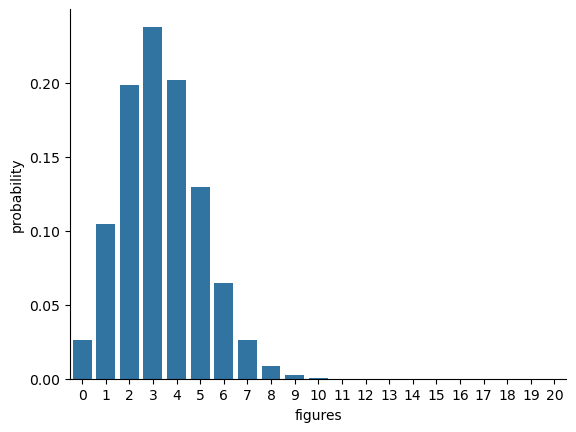

In [22]:
import pandas as pd
import seaborn as sns
from scipy.stats import binom

N = 20
rk = list(range(0, N+1, 1))
p = 1/6

y = binom.pmf(k=rk, n=N, p=p)

df = pd.DataFrame(
    {'probability': y,
     'figures': rk,
    }) 

fig = sns.barplot(x='figures', y='probability', data=df)

sns.despine()

In [23]:
from scipy.stats import binom

N = 20
p = 1/6
k = 4
p4 = binom.pmf(k=k, n=N, p=p)

print(f"La probabilité d'obtenir {k} figures en {N} jets est {p4:.4f}")

La probabilité d'obtenir 4 figures en 20 jets est 0.2022


### Distribution normale (ou gaussienne)

**Pourquoi on en parle autant ?** Parce que la loi normale apparaît **partout** en pratique : taille des adultes, erreurs de mesure, bruit sur un capteur, QI, notes à un examen... Un théorème très puissant (le *théorème central limite*) explique pourquoi : dès qu'une valeur est le résultat de **beaucoup de petits effets aléatoires** qui s'ajoutent, elle tend à suivre une loi normale. Sa courbe en **cloche** est la forme la plus emblématique de toutes les statistiques.

**Deux paramètres suffisent à la décrire :**
- la **moyenne** $\mu$ (lettre grecque « mu ») : où se trouve le sommet de la cloche — *le centre*.
- l'**écart-type** $\sigma$ (« sigma ») : la largeur de la cloche — *à quel point c'est étalé*.

Plus $\sigma$ est grand, plus la cloche est large et écrasée ; plus il est petit, plus elle est fine et piquée.

Lorsqu'une variable aléatoire $X$ suit une loi normale de moyenne $\mu$ et d'écart-type $\sigma$, on note :

$
\Large{
X \sim \mbox{Normal}(\mu,\sigma)}
$

**Propriété à connaître (règle des 68/95/99) :**
- ≈ **68%** des valeurs sont à moins d'**1 écart-type** de la moyenne.
- ≈ **95%** des valeurs sont à moins de **2 écarts-types**.
- ≈ **99,7%** des valeurs sont à moins de **3 écarts-types**.

C'est ce qui rend l'écart-type si parlant quand les données sont à peu près gaussiennes.

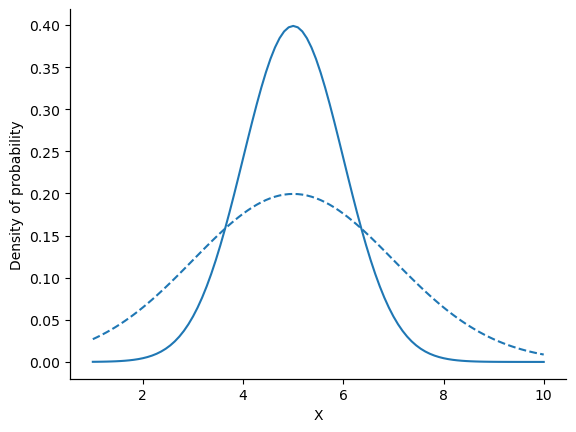

In [24]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

mu = 5

variance1 = 1
sigma1 = np.sqrt(variance1)
x = np.linspace(1, 10, 100)
y1 = stats.norm.pdf(x, mu, sigma1)

variance2 = 4
sigma2 = np.sqrt(variance2)
y2 = stats.norm.pdf(x, mu, sigma2)

fig = sns.lineplot(x = x, y = y1)
fig.set_xlabel("X")
fig.set_ylabel("Density of probability")

ax2=fig.twiny()
ax2.tick_params(left=False, labelleft=False, top=False, labeltop=False,
                right=False, labelright=False, bottom=False, labelbottom=False)
sns.lineplot(x = x, y = y2, ax=ax2, linestyle='--')

sns.despine()

On a affaire à une distribution de probabilités, $X$ étant une v.a. (variable aléatoire) continue

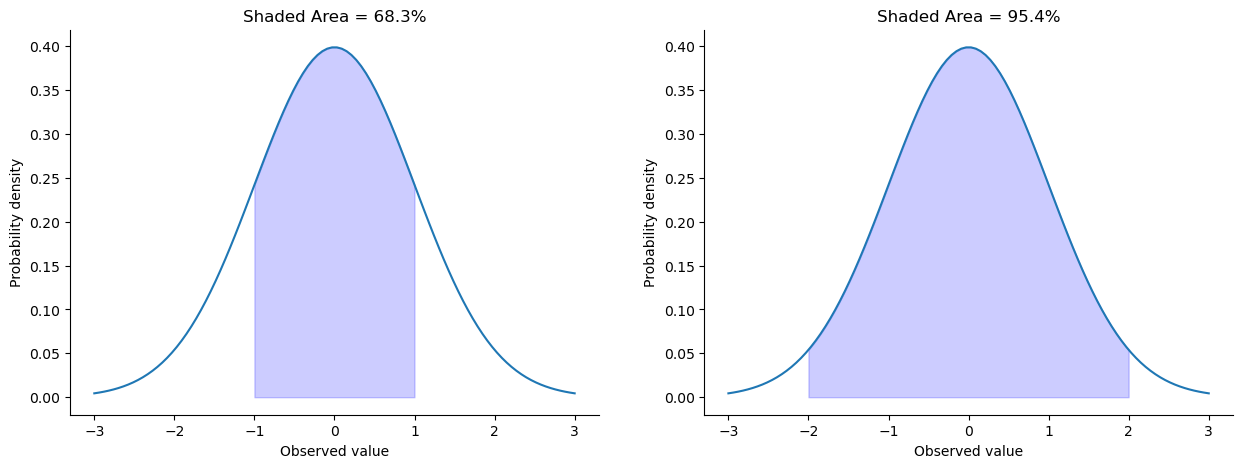

In [25]:
import numpy as np
import scipy.stats as stats
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

mu = 0
variance = 1
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
sns.lineplot(x = x, y = stats.norm.pdf(x, mu, sigma), ax=axes[0])
sns.lineplot(x = x, y = stats.norm.pdf(x, mu, sigma), ax=axes[1])

x_fill1 = np.arange(-1, 1, 0.001)
x_fill2 = np.arange(-2, 2, 0.001)

y_fill1 = stats.norm.pdf(x_fill1, mu, sigma)
y_fill2 = stats.norm.pdf(x_fill2, mu, sigma)

axes[0].fill_between(x_fill1, y_fill1,0, alpha=0.2, color='blue')
axes[1].fill_between(x_fill2, y_fill2,0, alpha=0.2, color='blue')

axes[0].set_title("Shaded Area = 68.3%")
axes[1].set_title("Shaded Area = 95.4%")

axes[0].set(xlabel='Observed value', ylabel='Probability density')
axes[1].set(xlabel='Observed value', ylabel='Probability density')

sns.despine()

> **🎯 À quoi sert la loi normale en data science ?**
>
> Elle est partout pour **trois raisons pratiques** :
>
> **1. Modéliser le bruit et les erreurs de mesure.** Un capteur de température, un prix qui fluctue, une mesure physique : on suppose souvent que le bruit suit une gaussienne. Beaucoup d'algorithmes (régression linéaire, moindres carrés, filtre de Kalman) **reposent explicitement** sur cette hypothèse.
>
> **2. Standardiser (normaliser) les features.** Avant d'entraîner un modèle, on transforme souvent chaque colonne par $z = \frac{x - \mu}{\sigma}$. Ça centre les données autour de 0 avec un écart-type de 1 — essentiel pour des algorithmes comme **KNN, SVM, régression régularisée, réseaux de neurones, PCA**, qui sont sensibles à l'échelle.
>
> **3. Tests statistiques et intervalles de confiance.** Les affirmations comme *« le CA moyen est de 15 k€ ± 2 k€ avec 95% de confiance »* reposent sur la loi normale via le **théorème central limite** (dès qu'on fait une moyenne sur beaucoup d'observations, elle tend vers une gaussienne — même si les données de départ ne sont pas gaussiennes !).
>
> **La règle des 68/95/99** (vue juste au-dessus) est la raison pour laquelle l'écart-type est si parlant quand on peut raisonnablement supposer des données gaussiennes : elle donne une interprétation immédiate de la dispersion.

## Probabilités et statistiques

Un fabricant de thermomètres prélève aléatoirement 1000 thermomètres pour évaluer leur qualité.
Placés dans la même pièce à une température de 20°, ils mesurent une température variant autour de 20°

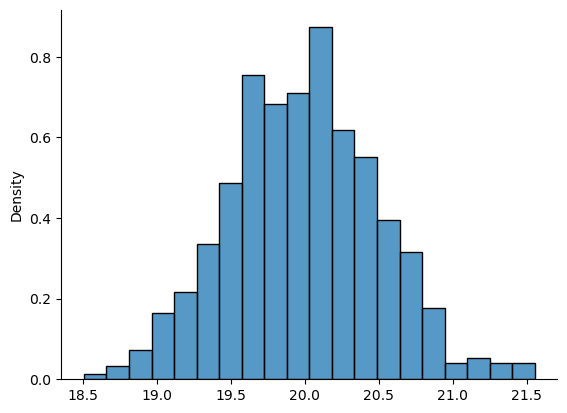

In [26]:
rand_gen = np.random.default_rng(seed=2)
temperature = 20
nb_thermometres = 1000

# Ce que les mesures ont donné.
# Evidemment, dans la vraie vie, nous ne générons pas nous mêmes les données,
# et on ne connait pas la loi statistique sous-jacente des données. 
temperatures = rand_gen.normal(loc=temperature, scale=0.5, size=nb_thermometres)

nb_bins = 20
sns.histplot(temperatures , bins=nb_bins, stat="density")
sns.despine();

La ditribution des données semble suivre une loi gaussienne.
On estime la moyenne et l'écart-type à partir des données de l'échantillon

In [27]:
mu_echantillon = temperatures.mean()
sigma_echantillon = temperatures.std(ddof=1)
print(f"Moyenne = {mu_echantillon:.2f}, écart-type = {sigma_echantillon:.2f}")

Moyenne = 19.99, écart-type = 0.51


Pour vérifier visuellement la qualité de notre hypothèse, on superpose aux données mesurées la densité de probabilité d'une loi normale

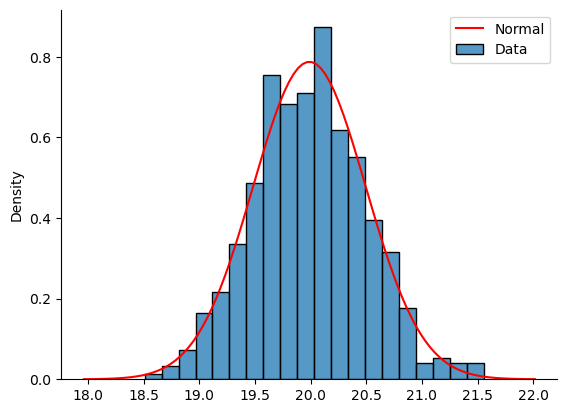

In [28]:
x = np.linspace(mu_echantillon - 4*sigma_echantillon, mu_echantillon + 4*sigma_echantillon, 100)
y = stats.norm.pdf(x, mu_echantillon, sigma_echantillon)
sns.histplot(temperatures , bins=nb_bins, stat="density", label="Data");
sns.lineplot(x=x, y=y, color='red', label='Normal')
plt.legend()
sns.despine()

## Skew et kurtosis

Moyenne, médiane, écart-type : on a de quoi décrire *le centre* et *l'étalement* d'une distribution. Mais deux distributions peuvent avoir les mêmes deux et ne pas se ressembler du tout. Pour aller plus loin, on regarde **la forme** de la distribution avec deux indicateurs : le **skew** (asymétrie) et le **kurtosis** (aplatissement).

### Skew (asymétrie)

**L'idée :** le skew mesure si la distribution **penche d'un côté**.

- Skew ≈ 0 → symétrique (comme la cloche gaussienne)
- Skew > 0 → la **traîne est à droite** (on dit « asymétrie positive » : quelques grosses valeurs tirent la queue à droite, cas typique des revenus ou des prix)
- Skew < 0 → la traîne est à gauche

![Skew](https://ethanweed.github.io/pythonbook/_images/e360b1388b6431fa2ca40a9c055a5d29504891086bc7dd4b01dffb032b43a0c1.png)

$
\Large{
    \mbox{skewness}(X) = \frac{1}{N \hat{\sigma}^3} \sum_{i=1}^N (X_i - \bar{X})^3
}
$

**Pourquoi élever au cube ?** Parce que le cube **conserve le signe** des écarts :
- un écart positif reste positif : $(+5)^3 = +125$
- un écart négatif reste négatif : $(-5)^3 = -125$

Du coup, si les écarts positifs (données à droite de la moyenne) dominent, la somme sera positive → skew positif. S'ils se compensent bien, le résultat est proche de 0 → distribution symétrique. La division par $\hat{\sigma}^3$ est là pour que le résultat soit **sans unité**, donc comparable entre jeux de données.

> **🎯 À quoi sert le skew en data science ?**
>
> C'est un **diagnostic** qu'on regarde *avant* d'entraîner un modèle.
>
> **Beaucoup de variables réelles sont fortement asymétriques** : revenus, prix immobiliers, durées de session web, nombre de vues d'une vidéo, taille des fichiers... Elles ont presque toujours une longue traîne à droite (skew > 0).
>
> **Pourquoi ça compte ?** Beaucoup de modèles — à commencer par la régression linéaire — fonctionnent mieux sur des données à peu près symétriques. Si le skew est élevé, le modèle sera **tiré par les quelques valeurs extrêmes** et médiocre sur les valeurs « normales ».
>
> **Solution classique :** appliquer une **transformation log** (ou Box-Cox, Yeo-Johnson) pour « symétriser » la variable avant l'entraînement :
>
> ```python
> df['prix_log'] = np.log1p(df['prix'])
> ```
>
> **Cas concret :** prédire le prix d'une maison. Sans `log`, le modèle est obsédé par les quelques villas à 5 M€ et prédit très mal les maisons normales. Avec `log`, les erreurs relatives sont équilibrées et le modèle devient fiable. C'est un réflexe à avoir dès qu'une variable est « à traîne ».

In [29]:
margins.skew(axis = 0, skipna = True)

np.float64(0.7804075289401982)

### Kurtosis (« pointu ou plat ? »)

**L'idée :** le kurtosis mesure à quel point les *queues* de la distribution sont épaisses comparées à une gaussienne.

- Kurtosis ≈ 0 → à peu près comme une gaussienne (convention utilisée par pandas : **kurtosis d'excès**, déjà « re-centrée » en retirant 3)
- Kurtosis > 0 → distribution **plus pointue** au centre avec des queues plus épaisses → **plus de valeurs extrêmes** que sous une gaussienne (données *à queue lourde*, attention aux outliers !)
- Kurtosis < 0 → distribution plus **aplatie** que la gaussienne, peu de valeurs extrêmes

![Kurtosis](https://ethanweed.github.io/pythonbook/_images/41b50af7ceb5a29356e05d18ac289fd90104487f22c8e3ece879d69d5de34be3.png)

$
\Large{
    \mbox{kurtosis}(X) = \frac{1}{N \hat\sigma^4} \sum_{i=1}^N \left( X_i - \bar{X} \right)^4  - 3
}
$

**Décodage :**
- On élève les écarts à la **puissance 4** (toujours positif, comme le carré, mais qui **amplifie énormément les gros écarts**) — c'est pour ça que le kurtosis est sensible aux queues.
- La division par $\hat{\sigma}^4$ rend la mesure sans unité.
- Le **$-3$** à la fin est une convention : il fait en sorte qu'une distribution gaussienne ait un kurtosis de $0$. C'est ce qu'on appelle le **kurtosis d'excès** (utilisé par `pandas`, `scipy`, etc.).

> **🎯 À quoi sert le kurtosis en data science ?**
>
> Le kurtosis répond à une question cruciale : *« mes données ont-elles beaucoup de valeurs extrêmes (outliers) ? »*. C'est une mesure de **l'épaisseur des queues** de la distribution.
>
> **Exemples typiques de données à queue lourde (kurtosis élevé) :**
> - **Rendements financiers** : les krachs boursiers arrivent bien plus souvent qu'une gaussienne ne le prédirait. Sous-estimer ce risque est littéralement à l'origine de la crise de 2008.
> - **Temps de réponse d'une API** : la plupart sont rapides, mais de temps en temps une requête explose à plusieurs secondes.
> - **Montants de transactions** : quelques très grosses opérations écrasent le reste.
>
> **Pourquoi ça compte ?**
> - Les modèles basés sur l'hypothèse gaussienne **sous-estiment le risque** si le kurtosis est élevé. Utiliser moyenne + écart-type pour détecter des anomalies sur des données à queue lourde donnera **trop de faux positifs** (tout est extrême) ou **trop de faux négatifs** (plus rien ne choque), selon l'angle.
> - **Solutions :**
>   - Préférer **médiane + IQR** aux mesures basées sur la moyenne (plus robustes).
>   - Utiliser des **distributions à queue lourde** (loi de Student, loi log-normale, Pareto) pour mieux modéliser.
>   - **Winsoriser** les données : couper les 1% les plus extrêmes avant modélisation.
>
> **À retenir :** toujours calculer `df.kurtosis()` sur ses variables numériques. Un kurtosis > 3 (ou > 0 en version « d'excès ») est un signal d'alerte : *« attention, les méthodes gaussiennes classiques vont sous-estimer le risque »*.

In [30]:
margins.kurtosis(axis = 0, skipna = True)

np.float64(0.10109718805638757)